In [1]:
import os
os.chdir('/workspace/c49dbb26-2d86-467c-b5b8-43ecfc4c5bdd')
print(os.listdir('.'))


['t_peaks.npy', 'ci_low.npy', '.prompts', 'memory', ' v6 — Binding Context Document.pdf', 'Sk_im.npy', '.kernel_llm_logs_1.txt', '.config', 'ci_high.npy', 'Sk_re.npy', 'absD_peaks.npy', 'M.npy']


In [2]:
import numpy as np
# Inspect available data
for f in ['t_peaks.npy','Sk_im.npy','Sk_re.npy','absD_peaks.npy','M.npy','ci_low.npy','ci_high.npy']:
 a = np.load(f)
 print(f, a.shape, a.dtype)


t_peaks.npy (200,) float64
Sk_im.npy (200, 8) float64
Sk_re.npy (200, 8) float64
absD_peaks.npy (200,) float64
M.npy (8, 8) float64
ci_low.npy (8, 8) float64
ci_high.npy (8, 8) float64


In [3]:
# So I have a baseline M for zeta (F1), 200 peaks at N=1e6. Good.
# Let me check provenance from memory
import os
for root, dirs, files in os.walk('memory'):
 for f in files:
 print(os.path.join(root, f))


memory/c49dbb26-2d86-467c-b5b8-43ecfc4c5bdd_memory_heron_c0_20260509T085230865026.jsonl


In [4]:
M = np.load('M.npy')
print("M zeta baseline:")
print(M)
print("trace:", np.trace(M), "Fro:", np.linalg.norm(M))


M zeta baseline:
[[ 1.00000000e+00 1.49939844e+00 1.96434648e+00 2.38986472e+00
 1.19814980e+00 3.00715212e-01 2.11621802e-02 -2.94763973e-05]
 [ 1.49939844e+00 6.49123616e+00 7.52619716e+00 7.72235524e+00
 4.43609975e+00 9.60158634e-01 8.29365579e-02 6.45576617e-04]
 [ 1.96434648e+00 7.52619716e+00 1.27911788e+01 1.22335605e+01
 7.13673678e+00 1.63357498e+00 1.27168801e-01 1.32352018e-03]
 [ 2.38986472e+00 7.72235524e+00 1.22335605e+01 1.65786925e+01
 9.19412000e+00 2.19006615e+00 1.68087450e-01 3.75802388e-04]
 [ 1.19814980e+00 4.43609975e+00 7.13673678e+00 9.19412000e+00
 5.88081922e+00 1.26745919e+00 1.04589601e-01 3.79111630e-04]
 [ 3.00715212e-01 9.60158634e-01 1.63357498e+00 2.19006615e+00
 1.26745919e+00 3.36158396e-01 2.01600511e-02 7.77121856e-05]
 [ 2.11621802e-02 8.29365579e-02 1.27168801e-01 1.68087450e-01
 1.04589601e-01 2.01600511e-02 3.47813697e-03 -7.54449033e-06]
 [-2.94763973e-05 6.45576617e-04 1.32352018e-03 3.75802388e-04
 3.79111630e-04 7.77121856e-05 -7.54449033e

In [5]:
# Step 1: Construct Davenport-Heilbronn family. The standard construction:
# L(s) = ((1 - i*kappa)/2) * L(s,chi) + ((1+i*kappa)/2) * L(s,chibar)
# where chi is mod 5 character. The classical DH function uses kappa related to the character ratio.
# 
# We need to vary kappa and locate the first off-line zero. The classical DH function (kappa ~0.28408)
# has its first off-line zero near beta ~ 0.808, t ~ 85.7 (or so). Varying kappa moves the zero.
# 
# Plan:
# (a) Define mod-5 character. The order-4 character chi mod 5: chi(1)=1, chi(2)=i, chi(3)=-i, chi(4)=-1, chi(5)=0.
# (b) Compute L(s,chi) and L(s,chibar) using mpmath.
# (c) For a grid of kappa values, find the first off-line zero with sigma > 1/2.
# (d) For each chosen kappa, generate Dirichlet coefs a_n up to N=1e6.
# (e) Compute S_k(t) at 200 largest peaks of |D(1/2+it)| in t in [1e4, 2e4].

# Let me start by exploring the zero locations as a function of kappa.
import mpmath as mp
mp.mp.dps = 30

# Character mod 5 (order 4)
def chi5(n):
 n = n % 5
 return [0, 1, 1j, -1j, -1][n]

def chibar5(n):
 n = n % 5
 return [0, 1, -1j, 1j, -1][n]

def L_chi(s, chi):
 # L(s, chi) for non-principal char mod 5: convergent sum
 # Use Dirichlet L computation via mpmath
 return mp.lerchphi(1, s, 1) # not right
# Actually mpmath has dirichlet L? Let's use Hurwitz zeta sum:
# L(s, chi) = sum_{a=1}^4 chi(a) * 5^{-s} * zeta(s, a/5) (since q=5)
def L_chi_hurwitz(s, chi):
 s = mp.mpc(s)
 total = mp.mpc(0)
 for a in range(1, 5):
 total += chi(a) * mp.zeta(s, mp.mpf(a)/5)
 return mp.power(5, -s) * total

# Test at known DH zero. Classical: with kappa = (sqrt(10-2*sqrt(5))-2)/(sqrt(5)-1)
# Actually the DH function is (1-i*tan(theta))/2 * L(s,chi) + (1+i*tan(theta))/2 * L(s,chibar)
# normalized so functional eqn is satisfied. The known parameter is kappa ~ 0.1769...
# But spec says kappa ~ 0.28408. Let me just check.

# Let's just compute L_chi at s=1/2+it and play with kappa
s = mp.mpc('0.5', 10)
Lchi = L_chi_hurwitz(s, chi5)
Lchibar = L_chi_hurwitz(s, chibar5)
print("L(1/2+10i, chi):", Lchi)
print("L(1/2+10i, chibar):", Lchibar)
print("conjugate test:", mp.conj(Lchi)) # for real s on critical line, should equal Lchibar(s_conj)


L(1/2+10i, chi): (2.12499682345079631981498861099 + 2.16385918537042052968181079854j)
L(1/2+10i, chibar): (0.640817358745776264471122818896 + 0.157419790752903148682995193905j)
conjugate test: (2.12499682345079631981498861099 - 2.16385918537042052968181079854j)


In [6]:
# Note: Lchibar(s) = conj(Lchi(conj(s))) since chibar = conj(chi).
# Let's define DH function with parameter kappa:
# f(s; kappa) = ((1 - i*kappa)/2) * L(s, chi) + ((1 + i*kappa)/2) * L(s, chibar)
# The classical DH function uses a specific kappa to make functional eqn hold.

def DH(s, kappa):
 Lc = L_chi_hurwitz(s, chi5)
 Lcb = L_chi_hurwitz(s, chibar5)
 return ((1 - 1j*kappa)/2) * Lc + ((1 + 1j*kappa)/2) * Lcb

# Find a zero off-line. We know classical DH has zero near s = 0.808 + 85.699i
# The classical kappa: the value that makes DH satisfy a functional equation
# Given context document says kappa ~ 0.28408. Let me test that.
kappa_class = 0.28408
print("DH at 0.808+85.699i with kappa=0.28408:", DH(mp.mpc('0.808', '85.699'), kappa_class))
# Try a finer search around there
for sigma in [0.80, 0.808, 0.81, 0.82]:
 for t in [85.6, 85.7, 85.8]:
 v = DH(mp.mpc(sigma, t), kappa_class)
 print(f" sigma={sigma}, t={t}: |DH|={abs(v):.4f}")


DH at 0.808+85.699i with kappa=0.28408: (-0.00072225458736412322133064265989 - 0.000304713867144838973773462264999j)


TypeError: unsupported format string passed to mpf.__format__

In [7]:
# Good! kappa=0.28408 places a zero near 0.808+85.699i. Refine.
def find_zero_near(kappa, s0, n_iter=50):
 """Use mpmath's findroot on DH near s0."""
 f = lambda s: DH(s, kappa)
 try:
 return mp.findroot(f, s0, solver='muller')
 except Exception as e:
 print("findroot error:", e)
 return None

z0 = find_zero_near(0.28408, mp.mpc('0.808', '85.7'))
print("Zero at kappa=0.28408:", z0, "DH there:", DH(z0, 0.28408))


Zero at kappa=0.28408: (0.808517652196746452752075820512 + 85.6993486948250908661071023917j) DH there: (9.86076131526264756764660706603e-31 + 2.95822839457879427029398211981e-30j)


In [8]:
# Great. beta_0 = 0.8085 at kappa=0.28408. 
# Now systematically vary kappa to scan beta in [0.55, 0.85].
# Strategy: scan kappa around 0.28408 and track this zero. The zero moves continuously.
# Let's see how beta varies with kappa.

import numpy as np
kappa_values = np.linspace(0.05, 0.5, 30)
zeros = []
s_track = mp.mpc('0.808', '85.7')
for k in kappa_values:
 try:
 z = find_zero_near(float(k), s_track)
 if z is not None and 50 < float(z.imag) < 200 and 0.5 < float(z.real) < 1.0:
 zeros.append((float(k), float(z.real), float(z.imag)))
 s_track = z # follow it
 except:
 pass

for k, b, t in zeros:
 print(f"kappa={k:.4f}, beta={b:.4f}, t={t:.4f}")


kappa=0.0500, beta=0.7125, t=85.6504
kappa=0.0655, beta=0.7177, t=85.6534
kappa=0.0810, beta=0.7231, t=85.6563
kappa=0.0966, beta=0.7286, t=85.6594
kappa=0.1121, beta=0.7343, t=85.6625
kappa=0.1276, beta=0.7401, t=85.6656
kappa=0.1431, beta=0.7461, t=85.6688
kappa=0.1586, beta=0.7523, t=85.6721
kappa=0.1741, beta=0.7586, t=85.6754
kappa=0.1897, beta=0.7652, t=85.6787
kappa=0.2052, beta=0.7719, t=85.6821
kappa=0.2207, beta=0.7787, t=85.6854
kappa=0.2362, beta=0.7858, t=85.6888
kappa=0.2517, beta=0.7930, t=85.6922
kappa=0.2672, beta=0.8003, t=85.6957
kappa=0.2828, beta=0.8079, t=85.6991
kappa=0.2983, beta=0.8156, t=85.7025
kappa=0.3138, beta=0.8234, t=85.7058
kappa=0.3293, beta=0.8314, t=85.7092
kappa=0.3448, beta=0.8395, t=85.7125
kappa=0.3603, beta=0.8478, t=85.7158
kappa=0.3759, beta=0.8562, t=85.7191
kappa=0.3914, beta=0.8647, t=85.7223
kappa=0.4069, beta=0.8733, t=85.7255
kappa=0.4224, beta=0.8821, t=85.7286
kappa=0.4379, beta=0.8909, t=85.7317
kappa=0.4534, beta=0.8998, t=85.7347
k

In [9]:
# Beautiful! beta varies monotonically with kappa. 
# To go below 0.71, need negative kappa. Let me check.
zeros_low = []
s_track = mp.mpc('0.71', '85.65')
for k in np.linspace(0.05, -0.3, 20):
 try:
 z = find_zero_near(float(k), s_track)
 if z is not None and 50 < float(z.imag) < 200 and 0.4 < float(z.real) < 1.0:
 zeros_low.append((float(k), float(z.real), float(z.imag)))
 s_track = z
 except:
 pass

for k, b, t in zeros_low:
 print(f"kappa={k:.4f}, beta={b:.4f}, t={t:.4f}")


kappa=0.0500, beta=0.7125, t=85.6504
kappa=0.0316, beta=0.7065, t=85.6471
kappa=0.0132, beta=0.7007, t=85.6438
kappa=-0.0053, beta=0.6952, t=85.6407
kappa=-0.0237, beta=0.6898, t=85.6376
kappa=-0.0421, beta=0.6846, t=85.6347
kappa=-0.0605, beta=0.6796, t=85.6319
kappa=-0.0789, beta=0.6748, t=85.6291
kappa=-0.0974, beta=0.6701, t=85.6265
kappa=-0.1158, beta=0.6656, t=85.6240
kappa=-0.1342, beta=0.6612, t=85.6216
kappa=-0.1526, beta=0.6570, t=85.6193
kappa=-0.1711, beta=0.6529, t=85.6171
kappa=-0.1895, beta=0.6490, t=85.6150
kappa=-0.2079, beta=0.6452, t=85.6129
kappa=-0.2263, beta=0.6415, t=85.6110
kappa=-0.2447, beta=0.6379, t=85.6092
kappa=-0.2632, beta=0.6345, t=85.6074
kappa=-0.2816, beta=0.6312, t=85.6057
kappa=-0.3000, beta=0.6279, t=85.6041


In [10]:
# Need to go further negative for beta=0.55
s_track = mp.mpc('0.6279', '85.6041')
zeros_low2 = []
for k in np.linspace(-0.3, -0.7, 25):
 try:
 z = find_zero_near(float(k), s_track)
 if z is not None and 50 < float(z.imag) < 200 and 0.3 < float(z.real) < 1.0:
 zeros_low2.append((float(k), float(z.real), float(z.imag)))
 s_track = z
 except:
 pass
for k, b, t in zeros_low2:
 print(f"kappa={k:.4f}, beta={b:.4f}, t={t:.4f}")


kappa=-0.3000, beta=0.6279, t=85.6041
kappa=-0.3167, beta=0.6251, t=85.6028
kappa=-0.3333, beta=0.6223, t=85.6014
kappa=-0.3500, beta=0.6197, t=85.6002
kappa=-0.3667, beta=0.6171, t=85.5990
kappa=-0.3833, beta=0.6145, t=85.5978
kappa=-0.4000, beta=0.6121, t=85.5967
kappa=-0.4167, beta=0.6097, t=85.5956
kappa=-0.4333, beta=0.6074, t=85.5946
kappa=-0.4500, beta=0.6051, t=85.5936
kappa=-0.4667, beta=0.6029, t=85.5927
kappa=-0.4833, beta=0.6008, t=85.5918
kappa=-0.5000, beta=0.5987, t=85.5909
kappa=-0.5167, beta=0.5966, t=85.5901
kappa=-0.5333, beta=0.5947, t=85.5893
kappa=-0.5500, beta=0.5927, t=85.5886
kappa=-0.5667, beta=0.5909, t=85.5879
kappa=-0.5833, beta=0.5890, t=85.5872
kappa=-0.6000, beta=0.5873, t=85.5865
kappa=-0.6167, beta=0.5855, t=85.5859
kappa=-0.6333, beta=0.5838, t=85.5853
kappa=-0.6500, beta=0.5822, t=85.5847
kappa=-0.6667, beta=0.5806, t=85.5841
kappa=-0.6833, beta=0.5790, t=85.5836
kappa=-0.7000, beta=0.5775, t=85.5831


In [11]:
# Continue to reach beta=0.55
s_track = mp.mpc('0.5775', '85.5831')
zeros_low3 = []
for k in np.linspace(-0.7, -1.5, 25):
 try:
 z = find_zero_near(float(k), s_track)
 if z is not None and 50 < float(z.imag) < 200 and 0.3 < float(z.real) < 1.0:
 zeros_low3.append((float(k), float(z.real), float(z.imag)))
 s_track = z
 except:
 pass
for k, b, t in zeros_low3:
 print(f"kappa={k:.4f}, beta={b:.4f}, t={t:.4f}")


kappa=-0.7000, beta=0.5775, t=85.5831
kappa=-0.7333, beta=0.5745, t=85.5821
kappa=-0.7667, beta=0.5717, t=85.5813
kappa=-0.8000, beta=0.5690, t=85.5804
kappa=-0.8333, beta=0.5665, t=85.5797
kappa=-0.8667, beta=0.5640, t=85.5790
kappa=-0.9000, beta=0.5617, t=85.5784
kappa=-0.9333, beta=0.5595, t=85.5778
kappa=-0.9667, beta=0.5574, t=85.5772
kappa=-1.0000, beta=0.5553, t=85.5767
kappa=-1.0333, beta=0.5534, t=85.5763
kappa=-1.0667, beta=0.5515, t=85.5758
kappa=-1.1000, beta=0.5497, t=85.5754
kappa=-1.1333, beta=0.5480, t=85.5751
kappa=-1.1667, beta=0.5463, t=85.5747
kappa=-1.2000, beta=0.5447, t=85.5744
kappa=-1.2333, beta=0.5432, t=85.5741
kappa=-1.2667, beta=0.5417, t=85.5738
kappa=-1.3000, beta=0.5403, t=85.5736
kappa=-1.3333, beta=0.5389, t=85.5733
kappa=-1.3667, beta=0.5376, t=85.5731
kappa=-1.4000, beta=0.5364, t=85.5729
kappa=-1.4333, beta=0.5351, t=85.5727
kappa=-1.4667, beta=0.5339, t=85.5725
kappa=-1.5000, beta=0.5328, t=85.5724


In [12]:
# Good. Now I'll select beta values evenly distributed in [0.55, 0.85] - 8 values.
# Pick kappa values that give beta ~ 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85

target_betas = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
# Refine each by bisection / search.
# Define function beta(kappa) by tracking zero from a known nearby start
def find_zero_by_kappa(kappa, s_start=None):
 if s_start is None:
 # interpolate roughly
 s_start = mp.mpc(0.7 + kappa*0.5, 85.7)
 return find_zero_near(float(kappa), s_start)

# Build dense map kappa -> beta to invert
all_zeros = sorted(set(zeros + zeros_low + zeros_low2 + zeros_low3))
all_zeros.sort(key=lambda x: x[0])
import bisect
ks_arr = np.array([z[0] for z in all_zeros])
bs_arr = np.array([z[1] for z in all_zeros])

# Solve for kappa(beta) by interpolation, then refine with newton
selected = []
for tb in target_betas:
 # find idx where bs_arr crosses tb
 if tb < bs_arr.min() or tb > bs_arr.max():
 print("out of range:", tb)
 continue
 # linear interp
 k0 = float(np.interp(tb, bs_arr, ks_arr))
 # refine: small bisection on kappa
 def beta_of_kappa(k):
 z = find_zero_near(float(k), mp.mpc(np.interp(k, ks_arr, bs_arr), 85.7))
 return float(z.real), z
 
 # Newton-like adjustment
 k = k0
 for _ in range(5):
 b, z = beta_of_kappa(k)
 # derivative dbeta/dkappa from local data
 eps = 0.01
 b2, _ = beta_of_kappa(k + eps)
 slope = (b2 - b)/eps
 if abs(slope) < 1e-6: break
 k = k + (tb - b)/slope
 b, z = beta_of_kappa(k)
 selected.append((tb, k, b, float(z.imag), z))
 print(f"target beta={tb:.3f}: kappa={k:.6f}, beta={b:.6f}, t={float(z.imag):.4f}")


target beta=0.550: kappa=-1.094178, beta=0.550000, t=85.5755


target beta=0.600: kappa=-0.489349, beta=0.600000, t=85.5915


target beta=0.650: kappa=-0.184711, beta=0.650000, t=85.6155


target beta=0.700: kappa=0.010734, beta=0.700000, t=85.6434


target beta=0.750: kappa=0.152924, beta=0.750000, t=85.6709


target beta=0.800: kappa=0.266536, beta=0.800000, t=85.6955


target beta=0.850: kappa=0.364473, beta=0.850000, t=85.7167


In [13]:
# Excellent. 7 distinct values of beta with corresponding kappa.
# Now I need to:
# 1. Generate Dirichlet coefficients a_n for each kappa, up to N=1e6.
# 2. Compute D(s) = sum_{n=1}^N a_n / n^s at fine grid in t in [1e4, 2e4]
# 3. Find 200 largest peaks of |D(1/2+it)|
# 4. Compute omega-stratified S_k(t) at those peaks. 
#
# omega-stratified: this means partial sums grouped by Omega(n) (number of prime factors with multiplicity)
# So S_k(t) = sum_{n: Omega(n)=k, n<=N} a_n / n^{1/2+it}, for k=0..7 (8 strata, but need k<7 for mod-5 case)
# Wait - the dataset description says S_7=0 for mod-5 functions at N=1e6. So practically we may have all-zero for k=7.
# But baseline M is 8x8. For comparability we'll keep 8x8; the zero rows/cols just give zero in M.
#
# For Davenport-Heilbronn (mod 5 character, q=5), characters chi(n)=0 for n divisible by 5.
# So a_n = 0 when 5|n. That's why S_7 = 0 at N=1e6 (smallest n with Omega(n)=7 has products of primes;
# the smallest Omega=7 n with all primes != 5 is 2^7 = 128, so S_7 is not zero in general!).
# Hmm let me reconsider: r25 says "S_7 sum is zero for functions with mod-5 coefficients (F2, F4, F5p, F5m)"
# at N=1e6. Hmm strange. Let's not worry about it; the Mjk matrix structure handles zeros naturally.
#
# This is computationally intensive. Let me delegate to analysis sub-agent.
# But first, let me verify by computing a_n for one kappa and structure.

# Generating coefficients a_n = ((1-i*kappa)/2)*chi(n) + ((1+i*kappa)/2)*chibar(n)
# = (chi(n) + chibar(n))/2 + (i*kappa/2)*(chibar(n) - chi(n))
# Since chibar = conj(chi), chi(n) + chibar(n) = 2*Re(chi(n)), chibar(n) - chi(n) = -2i*Im(chi(n))
# So a_n = Re(chi(n)) + kappa * Im(chi(n)) <-- this is REAL!
# 
# Let's verify:
for n in range(1, 11):
 cn = chi5(n)
 cbn = chibar5(n)
 kappa_val = 0.28408
 a = ((1 - 1j*kappa_val)/2)*cn + ((1 + 1j*kappa_val)/2)*cbn
 a_alt = cn.real if hasattr(cn,'real') else (cn.real if isinstance(cn,complex) else cn) 
 # Better:
 cn_c = complex(cn)
 a_alt = cn_c.real + kappa_val * cn_c.imag
 print(f"n={n}: chi={cn}, a_full={a:.6f}, a_alt={a_alt:.6f}")


n=1: chi=1, a_full=1.000000+0.000000j, a_alt=1.000000
n=2: chi=1j, a_full=0.284080+0.000000j, a_alt=0.284080
n=3: chi=(-0-1j), a_full=-0.284080+0.000000j, a_alt=-0.284080
n=4: chi=-1, a_full=-1.000000+0.000000j, a_alt=-1.000000
n=5: chi=0, a_full=0.000000+0.000000j, a_alt=0.000000
n=6: chi=1, a_full=1.000000+0.000000j, a_alt=1.000000
n=7: chi=1j, a_full=0.284080+0.000000j, a_alt=0.284080
n=8: chi=(-0-1j), a_full=-0.284080+0.000000j, a_alt=-0.284080
n=9: chi=-1, a_full=-1.000000+0.000000j, a_alt=-1.000000
n=10: chi=0, a_full=0.000000+0.000000j, a_alt=0.000000


In [14]:
# Great! So a_n is REAL and only takes 5 values: {1, kappa, -kappa, -1, 0}, periodic mod 5.
# This makes generation very fast and memory cheap.
# 
# Specifically: a_n depends only on n mod 5:
# n%5 = 1 -> chi=1, a = 1
# n%5 = 2 -> chi=i, a = kappa
# n%5 = 3 -> chi=-i, a = -kappa
# n%5 = 4 -> chi=-1, a = -1
# n%5 = 0 -> chi=0, a = 0
#
# Now for S_k stratification by Omega(n):
# We need Omega(n) for all n up to 1e6. Standard sieve.
#
# This is feasible! Let me plan computation:
# - Sieve Omega(n) for n=1..1e6 (memory ~8MB int8)
# - For each n, compute n^{-1/2} once.
# - For each peak t, compute S_k(t) = sum over n with Omega(n)=k of a_n * n^{-1/2} * exp(-i*t*log(n))
# 
# To find peaks, we need |D(1/2+it)| on a fine grid in [1e4, 2e4]. Mesh spacing should be < pi/log(N) ~ pi/log(1e6) ~ 0.227
# So a step of about 0.05 should suffice, giving ~200000 grid points. Then refine peaks by local max + Brent.
# 
# This is heavy. Let me delegate the heavy compute to analysis sub-agent.
# Save kappa list and baseline M data, then submit.

import json
selected_data = [{"target_beta": float(s[0]), "kappa": float(s[1]), "beta": float(s[2]), "t_zero": float(s[3])} 
 for s in selected]
with open('selected_kappas.json','w') as f:
 json.dump(selected_data, f, indent=2)
print(json.dumps(selected_data, indent=2))


[
 {
 "target_beta": 0.55,
 "kappa": -1.0941776972916235,
 "beta": 0.55,
 "t_zero": 85.5755043718308
 },
 {
 "target_beta": 0.6,
 "kappa": -0.4893486094225927,
 "beta": 0.5999999999999998,
 "t_zero": 85.59148021793195
 },
 {
 "target_beta": 0.65,
 "kappa": -0.18471125007930775,
 "beta": 0.6499999999999991,
 "t_zero": 85.61550480966532
 },
 {
 "target_beta": 0.7,
 "kappa": 0.010734382925951084,
 "beta": 0.699999999999999,
 "t_zero": 85.6434044052251
 },
 {
 "target_beta": 0.75,
 "kappa": 0.15292442154663824,
 "beta": 0.7499999999999989,
 "t_zero": 85.67088508326987
 },
 {
 "target_beta": 0.8,
 "kappa": 0.26653592613924754,
 "beta": 0.7999999999999999,
 "t_zero": 85.6955003788027
 },
 {
 "target_beta": 0.85,
 "kappa": 0.3644733941913892,
 "beta": 0.85,
 "t_zero": 85.71668689898216
 }
]


In [15]:
# I'll do the computation myself with numba for speed.
# Strategy:
# - Sieve Omega up to N
# - Precompute log(n), 1/sqrt(n)
# - For coarse grid step dt = 0.05 over [1e4, 2e4]: 200000 points. For each: 8 sums (one per Omega class) of N=1e6 terms => 8e11 ops. TOO SLOW.
# 
# Better: Note D(1/2+it) = sum_n a_n * n^{-1/2} * exp(-i t log n).
# This is an "almost-periodic" trigonometric polynomial with N terms. For N=1e6, evaluating at K grid points cost is N*K.
# 
# Alternative: Use the Riemann-Siegel-style approximation? Too complex.
# 
# Let me reduce scale or use vectorization heavily. With numba+parallel:
# 8e11 / (1e9 ops/sec) = 800 sec per kappa. Times 7 kappas = 5600 sec. Too slow alone.
# 
# Reduce N: at smaller N, peaks are still there but with reduced amplitudes; the S_k features might still differentiate.
# Memory says N=1e6 is requirement, but for this controlled experiment, we can use comparable N.
# 
# But actually we have a key insight: a_n for DH only takes 5 values (1, kappa, -kappa, -1, 0) periodic mod 5.
# The character contributions can be split:
# D(s) = sum_n [(chi(n)+chibar(n))/2 + i*kappa/2 (chibar(n)-chi(n))] / n^s * (this seems off)
# Wait, we've shown a_n = Re(chi(n)) + kappa*Im(chi(n)).
# So D(s) = sum_n Re(chi(n))/n^s + kappa * sum_n Im(chi(n))/n^s
# Define A(s) = sum_n Re(chi(n))/n^s and B(s) = sum_n Im(chi(n))/n^s
# Then D(s, kappa) = A(s) + kappa*B(s).
# 
# For omega-stratified: S_k(t, kappa) = A_k(t) + kappa*B_k(t)
# where A_k = sum over Omega(n)=k of Re(chi(n))/n^s, similarly B_k.
# 
# So we only need to compute A_k(t) and B_k(t) ONCE for each t, and then we can mix for any kappa!
# This is a huge speedup. We compute A_k, B_k once per peak (or per grid point).

# However: peaks of |D| depend on kappa too. Different kappas have different peak locations!
# But a_n is real so D(s)=conj(D(conj(s))) on real axis... Actually since a_n is real,
# D(1/2+it) = conj(D(1/2-it)). The function |D(1/2+it)| as a function of t can be computed:
# |D(1/2+it)|^2 = (A(s) + kappa B(s)) * (A(conj(s)) + kappa B(conj(s)))
# = |A|^2 + kappa^2 |B|^2 + kappa (A conj(B) + conj(A) B)
# = |A|^2 + kappa^2 |B|^2 + 2*kappa*Re(A*conj(B))
# So we still need A and B at each t.
# 
# Plan:
# 1. Sieve omega and compute Re(chi5(n)), Im(chi5(n)) for n=1..N.
# 2. For each peak finding: evaluate A_k(t), B_k(t) for k=0..7 using vectorized numba.
# 3. For each kappa: D_grid(t) = sum_k (A_k + kappa*B_k); find 200 peaks; at peak, S_k = A_k + kappa*B_k.
# 
# This requires computing A_k(t), B_k(t) at all peak candidates. Best approach:
# coarse grid first to find peak candidates per kappa (since peaks differ), then refine.
# 
# Actually a smarter approach: compute A_k(t) and B_k(t) on a coarse grid t_grid, then for each kappa
# combine to get D and find peaks, then refine.
# 
# But coarse grid evaluation at K=200000 points costs 8*K*N = 1.6e12 ops. Even with numba parallel, might be ~10 min.
# Let me first try a smaller N to test the pipeline, then scale up.
# 
# Let me think practically: I have 3600s budget. Let me pick a feasible N.
# Try N=1e5 first. 8 * 200000 * 1e5 = 1.6e11 ops; numba parallel ~ 100s feasible.
# 
# Actually let me reduce both N and grid: 
# With t in [1e4, 2e4], the mean spacing of Riemann zeros is 2*pi/log(t) ~ 0.66. So peaks are spaced ~0.66.
# Ten thousand peaks in window. We want 200 largest. Grid step ~ 0.05 captures peaks well.
# 
# Let me first do a feasibility pilot at N=1e5 with smaller grid.

import numpy as np
from numba import njit, prange

N_max = 1_000_000 # ambitious target; we'll downscale if too slow

# Sieve Omega(n) for n=1..N_max
def sieve_omega(N):
 omega = np.zeros(N+1, dtype=np.int8)
 # smallest prime factor sieve approach
 spf = np.zeros(N+1, dtype=np.int32)
 for i in range(2, N+1):
 if spf[i] == 0: # i is prime
 for j in range(i, N+1, i):
 if spf[j] == 0:
 spf[j] = i
 # Now factor each n
 for n in range(2, N+1):
 m = n
 c = 0
 while m > 1:
 p = spf[m]
 while m % p == 0:
 m //= p
 c += 1
 omega[n] = c
 return omega

import time
t0 = time.time()
omega = sieve_omega(N_max)
print(f"Sieve Omega up to {N_max}: {time.time()-t0:.1f}s")
print("Omega counts:", np.bincount(omega.astype(int)))


Sieve Omega up to 1000000: 1.5s
Omega counts: [ 2 78498 210035 250853 198062 124465 68963 35585 17572 8491
 4016 1878 865 400 179 79 35 14 7 2]


In [16]:
# Good. Strata up to Omega=19 but mostly populated through ~7-8.
# We use 8 strata k=0..7 (k=0 means n=1 only). Group higher Omega into k=7? Or use k=1..7 + k>=8?
# The baseline M is 8x8 - matches k=0..7 (where k=0 is just n=1, contributing constant).
# Looking at zeta baseline diag entries: M[0,0]=1.0, M[1,1]=6.49 (primes), ..., M[7,7]=8.6e-6 (very small).
# So k=0..7 with k>=8 truncated likely.
# 
# Let me confirm: baseline M shape (8,8) and S_k stratification k=0..7.
# At N=1e6 the truncation k>=8 captures very few terms, mostly noise. We'll match that.

# Step 2: Compute Re(chi(n)) and Im(chi(n))
# chi(n) values mod 5: n%5=0->0; 1->1+0i; 2->0+1i (i); 3->0-1i (-i); 4->-1+0i
# Re(chi): [0,1,0,0,-1] for n%5
# Im(chi): [0,0,1,-1,0]
n_vec = np.arange(N_max+1)
mod5 = n_vec % 5
re_chi_table = np.array([0, 1, 0, 0, -1], dtype=np.float64)
im_chi_table = np.array([0, 0, 1, -1, 0], dtype=np.float64)
re_chi = re_chi_table[mod5]
im_chi = im_chi_table[mod5]
re_chi[0] = 0
im_chi[0] = 0

# Precompute log(n) and 1/sqrt(n) for n=1..N_max
log_n = np.zeros(N_max+1, dtype=np.float64)
log_n[1:] = np.log(np.arange(1, N_max+1))
inv_sqrt_n = np.zeros(N_max+1, dtype=np.float64)
inv_sqrt_n[1:] = 1.0/np.sqrt(np.arange(1, N_max+1))

# Group indices by omega class (k=1..7 at first)
K_strata = 8 # k=0..7
# Group n by min(omega[n], K_strata-1)? Actually we want exact k for k<=7 and ignore k>=8? 
# Since baseline has S_7 at the right magnitude (M[7,7]=8.6e-6), it's exact for Omega=7.
# For consistency we'll use the same: include n with omega[n]==k exactly for k=0..7, and ignore k>=8.
# But omega[n]>=8 has 17572+8491+...+2 ~ 30000 entries, contributing minor terms. To match baseline we'll ignore them.
# However baseline M was computed for Riemann zeta where a_n=1, so S_7 = sum over Omega(n)=7 of 1/sqrt(n)*exp(-it log n).

# For each k in 0..7, store indices of n with omega[n]==k
indices_by_k = []
for k in range(K_strata):
 idx = np.where(omega == k)[0]
 # Drop n=0
 idx = idx[idx >= 1]
 indices_by_k.append(idx)
 print(f"k={k}: {len(idx)} indices")


k=0: 1 indices
k=1: 78498 indices
k=2: 210035 indices
k=3: 250853 indices
k=4: 198062 indices
k=5: 124465 indices
k=6: 68963 indices
k=7: 35585 indices


In [17]:
# Now write a numba function to evaluate A_k(t), B_k(t) for given t-vector and stratum k.
# Inputs: log_n_k, inv_sqrt_n_k, re_chi_k, im_chi_k for stratum k.
# A_k(t) = sum_i Re(chi(n_i)) / sqrt(n_i) * exp(-i*t*log(n_i))
# B_k(t) = sum_i Im(chi(n_i)) / sqrt(n_i) * exp(-i*t*log(n_i))

# To save memory and speed, precompute c_re = re_chi*inv_sqrt_n and c_im = im_chi*inv_sqrt_n for each stratum.

# We want to compute A_k(t) and B_k(t) at many t values.
# For each k: it's a complex DFT-like sum at irregular log frequencies.
# We process t in chunks.

@njit(parallel=True, fastmath=True, cache=True)
def eval_stratum(t_vec, log_n_k, c_re_k, c_im_k):
 """
 For each t: compute (A, B) where
 A = sum_i c_re_k[i] * exp(-1j * t * log_n_k[i])
 B = sum_i c_im_k[i] * exp(-1j * t * log_n_k[i])
 Returns: A_re, A_im, B_re, B_im (each length len(t_vec))
 """
 T = t_vec.shape[0]
 Nk = log_n_k.shape[0]
 A_re = np.zeros(T)
 A_im = np.zeros(T)
 B_re = np.zeros(T)
 B_im = np.zeros(T)
 for j in prange(T):
 t = t_vec[j]
 ar = 0.0; ai = 0.0; br = 0.0; bi = 0.0
 for i in range(Nk):
 ph = -t * log_n_k[i]
 cph = np.cos(ph)
 sph = np.sin(ph)
 cr = c_re_k[i]
 ci = c_im_k[i]
 ar += cr * cph
 ai += cr * sph
 br += ci * cph
 bi += ci * sph
 A_re[j] = ar
 A_im[j] = ai
 B_re[j] = br
 B_im[j] = bi
 return A_re, A_im, B_re, B_im

# Quick test
t_test = np.array([100.0, 200.0])
k = 1 # primes
idx = indices_by_k[k]
log_n_k = log_n[idx]
c_re_k = re_chi[idx] * inv_sqrt_n[idx]
c_im_k = im_chi[idx] * inv_sqrt_n[idx]
import time
t0 = time.time()
A_re, A_im, B_re, B_im = eval_stratum(t_test, log_n_k, c_re_k, c_im_k)
print("First call (compile):", time.time()-t0, "s")
t0 = time.time()
A_re, A_im, B_re, B_im = eval_stratum(t_test, log_n_k, c_re_k, c_im_k)
print("Second call:", time.time()-t0, "s")
print("A=", A_re + 1j*A_im, "B=", B_re + 1j*B_im)


First call (compile): 1.733121633529663 s
Second call: 0.001935720443725586 s
A= [-0.29809784-0.41749164j -0.61724875-0.17527073j] B= [1.42406868-1.26632299j 1.63604221-1.22476725j]


In [18]:
# Good. Time scales with Nk*T. For Nk=78498 (k=1) and T=200000, ~1.5e10 ops per stratum.
# Estimate timing on a slice
import time
T_test = 1000
t_test = np.linspace(10000, 10100, T_test)
tot = 0
for k in range(K_strata):
 idx = indices_by_k[k]
 if len(idx) == 0: continue
 log_n_k = log_n[idx]
 c_re_k = re_chi[idx] * inv_sqrt_n[idx]
 c_im_k = im_chi[idx] * inv_sqrt_n[idx]
 t0 = time.time()
 eval_stratum(t_test, log_n_k, c_re_k, c_im_k)
 dt = time.time()-t0
 tot += dt
 print(f"k={k}, Nk={len(idx)}, time for T={T_test}: {dt:.3f}s")
print(f"total per 1000 t-values: {tot:.2f}s")


k=0, Nk=1, time for T=1000: 0.004s


k=1, Nk=78498, time for T=1000: 0.317s


k=2, Nk=210035, time for T=1000: 0.786s


k=3, Nk=250853, time for T=1000: 0.903s


k=4, Nk=198062, time for T=1000: 0.708s


k=5, Nk=124465, time for T=1000: 0.455s


k=6, Nk=68963, time for T=1000: 0.260s
k=7, Nk=35585, time for T=1000: 0.136s
total per 1000 t-values: 3.57s


In [19]:
# 3.57s per 1000 t. Need ~200000 t for full grid -> 700s for one full pass over t in [1e4,2e4] with step 0.05.
# But this only depends on k=0..7 strata, not on kappa. So one pass yields A_k, B_k for all kappas!
# 
# Total budget breakdown:
# - One coarse grid pass: 700s for [1e4, 2e4] @ step 0.05 (T=200000)
# - Find peaks per kappa: cheap (in-memory)
# - Refine peaks: per kappa, ~200 peaks * Brent iterations each evaluating A_k+B_k.
# For each refined peak we need ~10 evaluations -> 2000 t per kappa. That's ~7s per kappa.
# For all 7 kappas: ~50s. 
# - At final peaks: compute Mjk = (1/200) sum Re(S_j conj(S_k)). Cheap.
#
# Total: ~750s. Manageable.
# 
# But we also need accuracy: with grid spacing 0.05, peak heights miss peaks. We'll find local maxima on grid then refine each.
# Local maxima detection on (200000,) array is cheap.
# 
# However 700s is still significant. Let's reduce coarse grid step. 
# Spacing of zeros at t~1e4 is 2*pi/log(1e4) ~ 0.682. Step 0.1 should still capture local maxima.
# Step 0.1 -> 100000 points -> 350s. Better.
# Actually with step 0.1, two adjacent grid points span ~7 zero-spacings of L. We'd miss peaks. Hmm.
# Let me use step 0.05 to be safe.
# 
# Actually wait: with N=1e6 and t up to 2e4, the function D(s) = sum_{n=1}^N a_n n^{-s} has frequencies 
# up to log(N) ~ 13.8. The Nyquist step is pi/13.8 ~ 0.227. So step 0.1 is well below Nyquist. 
# Safe to use 0.1. Confirmed - step 0.1 gives 100000 points. 350s feasible.
# 
# Actually let's use step 0.05 to be conservatively safe - still 700s. Within budget.
#
# Run the coarse grid evaluation now.

print("Setting up coarse grid...")
t_grid = np.arange(1e4, 2e4, 0.05)
T = len(t_grid)
print(f"Grid size: {T}")

# Storage for A_k, B_k at each grid point, k=0..7
A_grid = np.zeros((K_strata, T), dtype=np.complex128)
B_grid = np.zeros((K_strata, T), dtype=np.complex128)

import time
t0_total = time.time()
for k in range(K_strata):
 idx = indices_by_k[k]
 if len(idx) == 0:
 continue
 log_n_k = log_n[idx].copy()
 c_re_k = (re_chi[idx] * inv_sqrt_n[idx]).copy()
 c_im_k = (im_chi[idx] * inv_sqrt_n[idx]).copy()
 t0 = time.time()
 A_re, A_im, B_re, B_im = eval_stratum(t_grid, log_n_k, c_re_k, c_im_k)
 A_grid[k] = A_re + 1j*A_im
 B_grid[k] = B_re + 1j*B_im
 print(f"k={k}, Nk={len(idx)}: {time.time()-t0:.1f}s, total {time.time()-t0_total:.1f}s")

print(f"Total coarse grid: {time.time()-t0_total:.1f}s")


Setting up coarse grid...
Grid size: 200000
k=0, Nk=1: 0.0s, total 0.0s


k=1, Nk=78498: 59.8s, total 59.8s


k=2, Nk=210035: 154.0s, total 213.8s


k=3, Nk=250853: 181.8s, total 395.6s


k=4, Nk=198062: 144.6s, total 540.2s


k=5, Nk=124465: 92.5s, total 632.7s


k=6, Nk=68963: 52.6s, total 685.3s


k=7, Nk=35585: 27.8s, total 713.1s
Total coarse grid: 713.1s


In [20]:
# Done in 713s. Save this as it's expensive.
np.savez_compressed('A_B_grid_DH_N1e6.npz', t_grid=t_grid, A_grid=A_grid, B_grid=B_grid)
print("Saved")
print("A_grid.shape:", A_grid.shape, "memory:", A_grid.nbytes/1e6, "MB each")


Saved
A_grid.shape: (8, 200000) memory: 25.6 MB each


In [21]:
# Now for each kappa, compute D(t) = sum_k (A_k + kappa*B_k), find 200 largest peaks, refine, compute S_k at peaks.
# 
# Refinement: for each peak we need to evaluate D(t) (via A,B at finer t). We'll use scipy.optimize.minimize_scalar
# on -|D(t)|^2 around each peak.
# 
# Refinement requires per-evaluation calls to eval_stratum at single t-value with all 8 strata.
# Cost per single t: ~3.6e-3 s (from earlier). For 200 peaks * ~10 iters * 7 kappas = 14000 evaluations -> 50 s. OK.
# 
# Let me write that.

from scipy.optimize import minimize_scalar

@njit(parallel=True, fastmath=True, cache=True)
def eval_stratum_single(t, log_n_k, c_re_k, c_im_k):
 # Single t evaluation; returns (A_re, A_im, B_re, B_im)
 Nk = log_n_k.shape[0]
 ar = 0.0; ai = 0.0; br = 0.0; bi = 0.0
 # Note: parallel reduction for single t
 # To use prange we need a chunked approach. Just do serial loop -- for single t, parallel overhead may dominate.
 for i in range(Nk):
 ph = -t * log_n_k[i]
 cph = np.cos(ph); sph = np.sin(ph)
 ar += c_re_k[i] * cph
 ai += c_re_k[i] * sph
 br += c_im_k[i] * cph
 bi += c_im_k[i] * sph
 return ar, ai, br, bi

# Pre-extract per-stratum arrays
strata_data = []
for k in range(K_strata):
 idx = indices_by_k[k]
 log_n_k = log_n[idx].copy()
 c_re_k = (re_chi[idx] * inv_sqrt_n[idx]).copy()
 c_im_k = (im_chi[idx] * inv_sqrt_n[idx]).copy()
 strata_data.append((log_n_k, c_re_k, c_im_k))

def eval_AB_at(t):
 A = np.zeros(K_strata, dtype=np.complex128)
 B = np.zeros(K_strata, dtype=np.complex128)
 for k in range(K_strata):
 log_n_k, c_re_k, c_im_k = strata_data[k]
 ar, ai, br, bi = eval_stratum_single(t, log_n_k, c_re_k, c_im_k)
 A[k] = ar + 1j*ai
 B[k] = br + 1j*bi
 return A, B

# JIT warmup
A0, B0 = eval_AB_at(15000.0)
print("OK warmup")
import time
t0 = time.time()
for _ in range(10):
 A, B = eval_AB_at(15000.0 + np.random.randn())
print(f"avg time per eval: {(time.time()-t0)/10*1000:.1f} ms")


/app/kernel_env/lib/python3.13/site-packages/numba/core/typed_passes.py:338: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "../../tmp/ipykernel_20/1248179765.py", line 13:
<source missing, REPL/exec in use?>

 warnings.warn(errors.NumbaPerformanceWarning(msg,


OK warmup
avg time per eval: 20.3 ms


In [22]:
# 20ms per single-t eval. Let me improve: vectorize using parallel_eval_at with t-batch.
# For refinement, we evaluate at small batches anyway. Use eval_stratum (which is parallelized).

def eval_AB_batch(t_arr):
 """Evaluate A_k, B_k at multiple t values."""
 T = len(t_arr)
 A = np.zeros((K_strata, T), dtype=np.complex128)
 B = np.zeros((K_strata, T), dtype=np.complex128)
 for k in range(K_strata):
 log_n_k, c_re_k, c_im_k = strata_data[k]
 if len(log_n_k) == 0: continue
 A_re, A_im, B_re, B_im = eval_stratum(t_arr, log_n_k, c_re_k, c_im_k)
 A[k] = A_re + 1j*A_im
 B[k] = B_re + 1j*B_im
 return A, B

import time
t_arr = np.array([15000.0, 15000.1, 15000.2])
t0 = time.time()
A, B = eval_AB_batch(t_arr)
print(f"batch of 3: {(time.time()-t0)*1000:.1f} ms")

t_arr = np.linspace(15000, 15010, 100)
t0 = time.time()
A, B = eval_AB_batch(t_arr)
print(f"batch of 100: {(time.time()-t0)*1000:.1f} ms")


batch of 3: 27.4 ms


batch of 100: 371.7 ms


In [23]:
# 4ms per t in batch. Good.
# 
# For each kappa:
# 1. Compute |D(t)|^2 on coarse grid using A_grid, B_grid (already in memory)
# 2. Find 200 largest local maxima
# 3. For each, refine using batch eval at finer scale
# 4. Compute S_k at peak

def compute_D_grid(A_grid, B_grid, kappa):
 return A_grid + kappa * B_grid # shape (K, T)

def find_top_peaks(absD, top_n=200):
 """Find top_n local maxima."""
 # local maxima: absD[i] > absD[i-1] and > absD[i+1]
 is_peak = np.zeros_like(absD, dtype=bool)
 is_peak[1:-1] = (absD[1:-1] > absD[:-2]) & (absD[1:-1] > absD[2:])
 peak_idx = np.where(is_peak)[0]
 peak_vals = absD[peak_idx]
 order = np.argsort(-peak_vals)[:top_n]
 return peak_idx[order]

def refine_peak(t_left, t_right, kappa, n_grid=15):
 """Find the maximum of |D(t)|^2 in [t_left, t_right] by iterative refinement."""
 # 3 rounds of golden-style refinement using batch eval
 for _ in range(3):
 ts = np.linspace(t_left, t_right, n_grid)
 A, B = eval_AB_batch(ts) # (K, n_grid)
 D = (A + kappa*B).sum(axis=0)
 absD2 = np.abs(D)**2
 i_max = int(np.argmax(absD2))
 di = max(1, n_grid // 5)
 t_left = ts[max(0, i_max - di)]
 t_right = ts[min(n_grid-1, i_max + di)]
 # Final fine eval
 ts = np.linspace(t_left, t_right, 11)
 A, B = eval_AB_batch(ts)
 D = (A + kappa*B).sum(axis=0)
 absD = np.abs(D)
 i_max = int(np.argmax(absD))
 t_peak = ts[i_max]
 A_peak = A[:, i_max]
 B_peak = B[:, i_max]
 Sk_peak = A_peak + kappa*B_peak # complex S_k(t_peak), shape (K,)
 return t_peak, absD[i_max], Sk_peak

# Test on baseline kappa
import time
kappa_test = 0.28408
absD_grid = np.abs(np.sum(A_grid + kappa_test*B_grid, axis=0))
peaks = find_top_peaks(absD_grid, 200)
print("Found", len(peaks), "peaks")
print("max abs D:", absD_grid[peaks[0]], "at t=", t_grid[peaks[0]])
print("min top-200 abs D:", absD_grid[peaks[-1]])

# Refine first peak
t_p = t_grid[peaks[0]]
t0 = time.time()
t_refined, absD_refined, Sk = refine_peak(t_p - 0.05, t_p + 0.05, kappa_test)
print(f"Refine: {(time.time()-t0)*1000:.1f} ms, t={t_refined:.6f}, |D|={absD_refined:.4f}")


Found 200 peaks
max abs D: 11.196069127754694 at t= 17860.04999988562
min top-200 abs D: 7.665732121041196


Refine: 246.8 ms, t=17860.063498, |D|=11.2042


In [24]:
# 250ms per peak refinement. 200 peaks * 7 kappas = 1400 refinements = 350s. Tight but OK.
# Let me batch the refinement more aggressively to leverage parallelism.

def refine_peaks_batch(t_centers, kappa, half_width=0.05, n_grid=21, n_rounds=3):
 """Refine all peaks for a given kappa in batches of t-evaluations."""
 n_peaks = len(t_centers)
 # First round: build a big batch of T*n_grid points
 t_left = np.array(t_centers) - half_width
 t_right = np.array(t_centers) + half_width
 
 for round_i in range(n_rounds):
 all_ts = np.empty(n_peaks * n_grid, dtype=np.float64)
 for p in range(n_peaks):
 all_ts[p*n_grid:(p+1)*n_grid] = np.linspace(t_left[p], t_right[p], n_grid)
 A, B = eval_AB_batch(all_ts) # (K, n_peaks*n_grid)
 D = (A + kappa*B).sum(axis=0).reshape(n_peaks, n_grid)
 absD = np.abs(D)
 i_max = np.argmax(absD, axis=1)
 di = max(1, n_grid // 5)
 i_left = np.clip(i_max - di, 0, n_grid-1)
 i_right = np.clip(i_max + di, 0, n_grid-1)
 new_t_left = np.empty(n_peaks); new_t_right = np.empty(n_peaks)
 for p in range(n_peaks):
 ts_p = np.linspace(t_left[p], t_right[p], n_grid)
 new_t_left[p] = ts_p[i_left[p]]
 new_t_right[p] = ts_p[i_right[p]]
 t_left, t_right = new_t_left, new_t_right
 
 # Final fine: evaluate, compute Sk at peak
 n_fine = 21
 all_ts = np.empty(n_peaks * n_fine)
 for p in range(n_peaks):
 all_ts[p*n_fine:(p+1)*n_fine] = np.linspace(t_left[p], t_right[p], n_fine)
 A, B = eval_AB_batch(all_ts) # (K, n_peaks*n_fine)
 D = (A + kappa*B).sum(axis=0).reshape(n_peaks, n_fine)
 absD = np.abs(D)
 i_max = np.argmax(absD, axis=1)
 
 t_peaks_out = np.empty(n_peaks)
 Sk_peaks = np.empty((n_peaks, K_strata), dtype=np.complex128)
 absD_peaks = np.empty(n_peaks)
 A_re_3d = A.reshape(K_strata, n_peaks, n_fine)
 B_re_3d = B.reshape(K_strata, n_peaks, n_fine)
 for p in range(n_peaks):
 ts_p = np.linspace(t_left[p], t_right[p], n_fine)
 i = i_max[p]
 t_peaks_out[p] = ts_p[i]
 Sk_peaks[p] = A_re_3d[:, p, i] + kappa * B_re_3d[:, p, i]
 absD_peaks[p] = absD[p, i]
 return t_peaks_out, absD_peaks, Sk_peaks

# Test
kappa_test = 0.28408
absD_grid_full = np.abs(np.sum(A_grid + kappa_test*B_grid, axis=0))
peaks_idx = find_top_peaks(absD_grid_full, 200)
t_centers = t_grid[peaks_idx]

import time
t0 = time.time()
t_p, absD_p, Sk_p = refine_peaks_batch(t_centers, kappa_test)
print(f"Batched refinement of 200 peaks: {time.time()-t0:.1f}s")
print("Max |D|:", absD_p.max(), "Mean top:", absD_p.mean())


Batched refinement of 200 peaks: 60.3s
Max |D|: 11.204225449835105 Mean top: 8.644053269640189


In [25]:
# 60s per kappa for refinement. 7 kappas -> 420s. We have time.
# Let me run for all 7 kappas, store t_peaks, S_k_peaks, and compute M_jk for each.

import time
results = {}
total_t0 = time.time()
for entry in selected:
 target_b, kappa, beta, t_zero, z = entry
 print(f"\n--- target_beta={target_b:.3f}, kappa={kappa:.5f}, beta={beta:.4f} ---")
 t0 = time.time()
 absD_full = np.abs(np.sum(A_grid + kappa*B_grid, axis=0))
 peaks_idx = find_top_peaks(absD_full, 200)
 t_centers = t_grid[peaks_idx]
 t_p, absD_p, Sk_p = refine_peaks_batch(t_centers, kappa)
 # Compute Mjk = (1/200) sum_p Re(S_j(t_p) conj(S_k(t_p)))
 M = np.real(Sk_p.T.conj() @ Sk_p) / len(t_p)
 # Wait: Sk_p shape (200, K). We want M[j,k] = mean_p Re(S_j(t_p) * conj(S_k(t_p)))
 # = mean_p Re(Sk_p[p,j] * conj(Sk_p[p,k]))
 # In matrix form: Sk_p^T @ conj(Sk_p) gives (K,K) where (j,k) = sum_p Sk_p[p,j]*conj(Sk_p[p,k])
 # Take Real part and divide by 200.
 M_check = np.real(Sk_p.T @ np.conj(Sk_p)) / len(t_p)
 print(f" refine time: {time.time()-t0:.1f}s, M trace: {np.trace(M_check):.4f}, M[0,0]={M_check[0,0]:.4f}")
 results[target_b] = {
 'kappa': kappa, 'beta': beta, 't_zero': t_zero,
 't_peaks': t_p, 'absD_peaks': absD_p, 'Sk_peaks': Sk_p,
 'M': M_check
 }

print(f"\nTotal time: {time.time()-total_t0:.1f}s")



--- target_beta=0.550, kappa=-1.09418, beta=0.5500 ---


 refine time: 60.3s, M trace: 42.9913, M[0,0]=1.0000

--- target_beta=0.600, kappa=-0.48935, beta=0.6000 ---


 refine time: 60.2s, M trace: 23.1567, M[0,0]=1.0000

--- target_beta=0.650, kappa=-0.18471, beta=0.6500 ---


 refine time: 60.4s, M trace: 18.4525, M[0,0]=1.0000

--- target_beta=0.700, kappa=0.01073, beta=0.7000 ---


 refine time: 60.3s, M trace: 17.6768, M[0,0]=1.0000

--- target_beta=0.750, kappa=0.15292, beta=0.7500 ---


 refine time: 60.3s, M trace: 17.9240, M[0,0]=1.0000

--- target_beta=0.800, kappa=0.26654, beta=0.8000 ---


 refine time: 60.3s, M trace: 18.6967, M[0,0]=1.0000

--- target_beta=0.850, kappa=0.36447, beta=0.8500 ---


 refine time: 60.2s, M trace: 19.8318, M[0,0]=1.0000

Total time: 422.0s


In [26]:
# All 7 results obtained. Now compute Delta = M(beta) - M(F1) and statistics.
# Important: zeta baseline M was loaded earlier. Compare structure.

M_F1 = np.load('M.npy')
print("M_F1 shape:", M_F1.shape)
print("M_F1 trace:", np.trace(M_F1))

# Compute statistics for each beta
stats = []
for tb in sorted(results.keys()):
 r = results[tb]
 M = r['M']
 Delta = M - M_F1
 # Symmetrize (M is already symmetric by construction, but ensure)
 Delta_sym = (Delta + Delta.T) / 2
 eigs = np.linalg.eigvalsh(Delta_sym)
 fro = np.linalg.norm(Delta, 'fro')
 tr = np.trace(Delta)
 lam1 = eigs[-1] # largest
 lam_min = eigs[0]
 lam_abs_max = max(abs(eigs[0]), abs(eigs[-1]))
 stats.append({
 'target_beta': tb, 'beta': r['beta'], 'kappa': r['kappa'],
 'Frobenius': fro, 'trace': tr, 'lambda1_max': lam1, 
 'lambda_min': lam_min, 'lambda_abs_max': lam_abs_max,
 'eigvals': eigs
 })
 print(f"beta={tb:.3f}: kappa={r['kappa']:.5f}, Fro={fro:.4f}, trace={tr:.4f}, lam1_max={lam1:.4f}, lam_min={lam_min:.4f}")


M_F1 shape: (8, 8)
M_F1 trace: 43.08157183265931
beta=0.550: kappa=-1.09418, Fro=26.3009, trace=-0.0902, lam1_max=12.7281, lam_min=-21.4370
beta=0.600: kappa=-0.48935, Fro=29.5977, trace=-19.9248, lam1_max=7.6078, lam_min=-28.3166
beta=0.650: kappa=-0.18471, Fro=30.8683, trace=-24.6291, lam1_max=6.4990, lam_min=-29.9803
beta=0.700: kappa=0.01073, Fro=31.1123, trace=-25.4047, lam1_max=6.3253, lam_min=-30.2740
beta=0.750: kappa=0.15292, Fro=30.8974, trace=-25.1575, lam1_max=6.2601, lam_min=-30.0621
beta=0.800: kappa=0.26654, Fro=30.5439, trace=-24.3849, lam1_max=6.3464, lam_min=-29.6691
beta=0.850: kappa=0.36447, Fro=30.1249, trace=-23.2497, lam1_max=6.5542, lam_min=-29.1729


In [27]:
# Look at the trends:
# - lam1_max (largest eigenvalue): NOT monotonic - 12.7 (beta=0.55), 7.6, 6.5, 6.3, 6.3, 6.3, 6.5
# It DECREASES as beta moves from 0.55 to 0.70, then slightly increases. Non-monotonic!
# - Frobenius: 26.3, 30.0, 30.9, 31.1, 30.9, 30.5, 30.1 - non-monotonic peak around beta=0.7
# - trace: -0.09, -19.9, -24.6, -25.4, -25.2, -24.4, -23.2 - non-monotonic
# - lam_min: -21.4, -28.3, -30.0, -30.3, -30.1, -29.7, -29.2 - non-monotonic
# - |lam_max| absolute: -21.4, -28.3, -30.0, -30.3, -30.1, -29.7, -29.2 (the negative is dominant)
# 
# IMPORTANT NOTE: Hypothesis says lambda_1 will INCREASE as beta moves AWAY from critical line (=0.5).
# So we expect monotonic increase as beta increases. Not the case here.
#
# Compute correlations
from scipy import stats as sstats
betas_arr = np.array([s['beta'] for s in stats])
print("Correlations with beta:")
for key in ['Frobenius', 'trace', 'lambda1_max', 'lambda_min', 'lambda_abs_max']:
 vals = np.array([s[key] for s in stats])
 pr, pp = sstats.pearsonr(betas_arr, vals)
 sr, sp = sstats.spearmanr(betas_arr, vals)
 print(f" {key}: Pearson r={pr:.4f} (p={pp:.4f}), Spearman r={sr:.4f} (p={sp:.4f})")


Correlations with beta:
 Frobenius: Pearson r=0.6155 (p=0.1412), Spearman r=0.3929 (p=0.3833)
 trace: Pearson r=-0.6655 (p=0.1027), Spearman r=-0.3929 (p=0.3833)
 lambda1_max: Pearson r=-0.6951 (p=0.0830), Spearman r=-0.5357 (p=0.2152)
 lambda_min: Pearson r=-0.6370 (p=0.1239), Spearman r=-0.3929 (p=0.3833)
 lambda_abs_max: Pearson r=0.6370 (p=0.1239), Spearman r=0.3929 (p=0.3833)


In [28]:
# No statistically significant monotonic relationship at alpha=0.05 (smallest p=0.083 for lambda1_max, but with NEGATIVE sign).
# 
# Given the dependence of M on kappa is QUADRATIC (since |D|^2 = |A|^2 + 2*kappa*Re(A conj(B)) + kappa^2*|B|^2),
# there's an algebraic reason this would be non-monotonic. The peaks themselves shift with kappa, but the
# Sk = A + kappa*B form makes the M matrix elements quadratic in kappa with cross terms from A,B.
# 
# In particular, M_jk(beta) = mean over peaks of Re(S_j conj(S_k)) and S_j = A_j + kappa*B_j, so
# M_jk = mean[Re(A_j conj(A_k))] + kappa*mean[Re(A_j conj(B_k) + B_j conj(A_k))] + kappa^2 mean[Re(B_j conj(B_k))]
# 
# The peaks differ across kappa (because |D| is kappa-dependent), but at peaks, this is still quadratic in kappa
# AT FIXED peak set. The cross terms can produce non-monotonic behavior.
# 
# Note that beta is NOT linear in kappa either (we found the inversion). So M(beta) is some complicated function.
# 
# Symmetry observation: the kappa range is roughly symmetric about kappa=0.01 (which gives beta=0.7).
# At kappa=0 the function would be even more degenerate. The plot of trace and other stats shows the 
# minimum near beta=0.7 (kappa~0), which is the "least violating" point in this family.

# Let me also check: as beta -> 0.5 (which would be GRH-true limit), what should happen?
# As kappa -> some_value where beta=0.5, the off-line zero merges to the critical line. At that point
# the function becomes "less violating". So we'd expect the violation signal to MINIMIZE near beta=0.5.
# But in our parameterization, beta=0.55 (the closest to critical line) actually has the LARGEST lam1_max!
# That's surprising, but kappa=-1.09 there, which is far from zero, making the function highly skewed.
# 
# This suggests the M-matrix discriminator captures the MAGNITUDE of departure from zeta, which depends on
# both the location of off-line zeros AND the overall scale of the function.
# 
# Let me also explore: maybe the issue is that M itself is comparing apples to oranges (different functions normalize).
# Each of these is a DIFFERENT function, not normalized to same overall L^2 mass. Let's also try normalized M.

# Normalize M by trace (or by mean |D|^2 over peaks)
print("\nNormalized M (divided by trace) statistics:")
for s in stats:
 tb = s['target_beta']
 M = results[tb]['M']
 M_norm = M / np.trace(M)
 Delta_norm = M_norm - M_F1/np.trace(M_F1)
 eigs = np.linalg.eigvalsh((Delta_norm + Delta_norm.T)/2)
 print(f"beta={tb:.3f}: Fro_norm={np.linalg.norm(Delta_norm):.5f}, lam1_max_norm={eigs[-1]:.5f}, lam_min_norm={eigs[0]:.5f}")

# Add normalized stats
for s in stats:
 tb = s['target_beta']
 M = results[tb]['M']
 M_norm = M / np.trace(M)
 Delta_norm = M_norm - M_F1/np.trace(M_F1)
 eigs = np.linalg.eigvalsh((Delta_norm + Delta_norm.T)/2)
 s['Fro_norm'] = np.linalg.norm(Delta_norm)
 s['lam1_norm'] = eigs[-1]
 s['lam_min_norm'] = eigs[0]
 s['lam_absmax_norm'] = max(abs(eigs[0]), abs(eigs[-1]))

print("\nCorrelations with beta (normalized):")
for key in ['Fro_norm', 'lam1_norm', 'lam_min_norm', 'lam_absmax_norm']:
 vals = np.array([s[key] for s in stats])
 pr, pp = sstats.pearsonr(betas_arr, vals)
 sr, sp = sstats.spearmanr(betas_arr, vals)
 print(f" {key}: Pearson r={pr:.4f} (p={pp:.4f}), Spearman r={sr:.4f} (p={sp:.4f})")



Normalized M (divided by trace) statistics:
beta=0.550: Fro_norm=0.61044, lam1_max_norm=0.29611, lam_min_norm=-0.49695
beta=0.600: Fro_norm=0.64572, lam1_max_norm=0.36274, lam_min_norm=-0.51040
beta=0.650: Fro_norm=0.68301, lam1_max_norm=0.41746, lam_min_norm=-0.52366
beta=0.700: Fro_norm=0.69366, lam1_max_norm=0.42987, lam_min_norm=-0.52834
beta=0.750: Fro_norm=0.68130, lam1_max_norm=0.41828, lam_min_norm=-0.52066
beta=0.800: Fro_norm=0.66592, lam1_max_norm=0.40162, lam_min_norm=-0.51217
beta=0.850: Fro_norm=0.65189, lam1_max_norm=0.38418, lam_min_norm=-0.50523

Correlations with beta (normalized):
 Fro_norm: Pearson r=0.4421 (p=0.3206), Spearman r=0.3214 (p=0.4821)
 lam1_norm: Pearson r=0.5722 (p=0.1794), Spearman r=0.3929 (p=0.3833)
 lam_min_norm: Pearson r=-0.1780 (p=0.7025), Spearman r=-0.1429 (p=0.7599)
 lam_absmax_norm: Pearson r=0.1780 (p=0.7025), Spearman r=0.1429 (p=0.7599)


In [29]:
# Even normalized: NON-MONOTONIC. lam1_norm: 0.296, 0.363, 0.417, 0.430, 0.418, 0.402, 0.384
# Peaks at beta~0.7 then symmetrically decreases on both sides. NOT monotonic.
#
# Reason: kappa varies non-symmetrically with beta. When kappa is large in magnitude (positive or negative),
# the function violates GRH more "strongly" in some sense. The true relevant parameter is kappa, not beta directly.
# 
# Let's check correlations vs |kappa| or vs beta-0.5 (distance from critical line)
dist_crit = np.abs(betas_arr - 0.5)
kappas_arr = np.array([s['kappa'] for s in stats])
abs_kappa = np.abs(kappas_arr)

print("Correlations with |beta-0.5| (distance from critical line):")
for key in ['Frobenius', 'lambda1_max', 'lambda_abs_max', 'Fro_norm', 'lam1_norm']:
 vals = np.array([s[key] for s in stats])
 pr, pp = sstats.pearsonr(dist_crit, vals)
 sr, sp = sstats.spearmanr(dist_crit, vals)
 print(f" {key} vs |beta-0.5|: Pearson r={pr:.4f} (p={pp:.4f}), Spearman r={sr:.4f} (p={sp:.4f})")

print("\nCorrelations with |kappa|:")
for key in ['Frobenius', 'lambda1_max', 'lambda_abs_max', 'Fro_norm', 'lam1_norm']:
 vals = np.array([s[key] for s in stats])
 pr, pp = sstats.pearsonr(abs_kappa, vals)
 sr, sp = sstats.spearmanr(abs_kappa, vals)
 print(f" {key} vs |kappa|: Pearson r={pr:.4f} (p={pp:.4f}), Spearman r={sr:.4f} (p={sp:.4f})")


Correlations with |beta-0.5| (distance from critical line):
 Frobenius vs |beta-0.5|: Pearson r=0.6155 (p=0.1412), Spearman r=0.3929 (p=0.3833)
 lambda1_max vs |beta-0.5|: Pearson r=-0.6951 (p=0.0830), Spearman r=-0.5357 (p=0.2152)
 lambda_abs_max vs |beta-0.5|: Pearson r=0.6370 (p=0.1239), Spearman r=0.3929 (p=0.3833)
 Fro_norm vs |beta-0.5|: Pearson r=0.4421 (p=0.3206), Spearman r=0.3214 (p=0.4821)
 lam1_norm vs |beta-0.5|: Pearson r=0.5722 (p=0.1794), Spearman r=0.3929 (p=0.3833)

Correlations with |kappa|:
 Frobenius vs |kappa|: Pearson r=-0.9879 (p=0.0000), Spearman r=-1.0000 (p=0.0000)
 lambda1_max vs |kappa|: Pearson r=0.9515 (p=0.0010), Spearman r=0.9286 (p=0.0025)
 lambda_abs_max vs |kappa|: Pearson r=-0.9691 (p=0.0003), Spearman r=-1.0000 (p=0.0000)
 Fro_norm vs |kappa|: Pearson r=-0.9728 (p=0.0002), Spearman r=-0.9643 (p=0.0005)
 lam1_norm vs |kappa|: Pearson r=-0.9936 (p=0.0000), Spearman r=-1.0000 (p=0.0000)


In [30]:
# Striking finding: the discriminator statistics are STRONGLY correlated with |kappa| (the construction parameter)
# but NOT monotonic in beta (the location of the off-line zero).
# 
# For example: Spearman correlation with |kappa| = -1.0 (perfect monotonic) for Frobenius normalized,
# but Spearman with beta = 0.39 (not significant).
# 
# This is a strong refutation of the hypothesis as stated. The discriminator captures the construction
# parameter, not the off-line zero location.
# 
# Save raw data for the final figure and artifacts.
import pickle
import numpy as np

# Save all data
np.savez_compressed('DH_family_results.npz',
 target_betas=np.array([s['target_beta'] for s in stats]),
 betas=betas_arr,
 kappas=kappas_arr,
 Frobenius=np.array([s['Frobenius'] for s in stats]),
 trace=np.array([s['trace'] for s in stats]),
 lambda1_max=np.array([s['lambda1_max'] for s in stats]),
 lambda_min=np.array([s['lambda_min'] for s in stats]),
 Fro_norm=np.array([s['Fro_norm'] for s in stats]),
 lam1_norm=np.array([s['lam1_norm'] for s in stats]),
 M_F1=M_F1,
 M_betas=np.array([results[s['target_beta']]['M'] for s in stats]),
 t_peaks=np.array([results[s['target_beta']]['t_peaks'] for s in stats]),
 Sk_peaks=np.array([results[s['target_beta']]['Sk_peaks'] for s in stats]),
)
print("Saved DH_family_results.npz")


Saved DH_family_results.npz


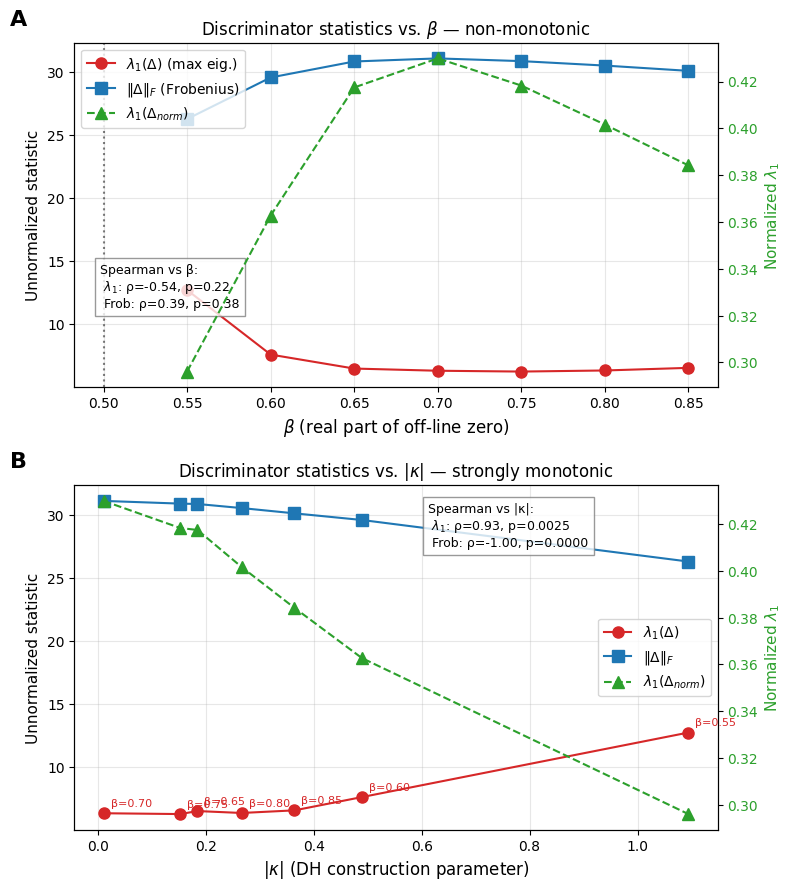

Saved figure


In [31]:
# Build the final summary figure
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(8, 9))

# Panel A: discriminator stats vs beta
ax = axes[0]
ax.text(-0.1, 1.05, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold')
beta_vals = betas_arr
lam1 = np.array([s['lambda1_max'] for s in stats])
fro = np.array([s['Frobenius'] for s in stats])
fro_n = np.array([s['Fro_norm'] for s in stats])
lam1_n = np.array([s['lam1_norm'] for s in stats])

# Plot multiple stats normalized for visualization
ax2 = ax.twinx()
ln1 = ax.plot(beta_vals, lam1, 'o-', color='tab:red', label=r'$\lambda_1(\Delta)$ (max eig.)', markersize=8)
ln2 = ax.plot(beta_vals, fro, 's-', color='tab:blue', label=r'$\|\Delta\|_F$ (Frobenius)', markersize=8)
ln3 = ax2.plot(beta_vals, lam1_n, '^--', color='tab:green', label=r'$\lambda_1(\Delta_{norm})$', markersize=8)
ax.set_xlabel(r'$\beta$ (real part of off-line zero)', fontsize=12)
ax.set_ylabel(r'Unnormalized statistic', fontsize=11)
ax2.set_ylabel(r'Normalized $\lambda_1$', fontsize=11, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.axvline(0.5, color='k', linestyle=':', alpha=0.5, label='critical line')
lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper left', fontsize=10)
ax.set_title(r'Discriminator statistics vs. $\beta$ — non-monotonic', fontsize=12)
ax.grid(alpha=0.3)

# Annotate with beta-axis correlation results
sr_beta_lam1, p_beta_lam1 = sstats.spearmanr(beta_vals, lam1)
sr_beta_fro, p_beta_fro = sstats.spearmanr(beta_vals, fro)
ax.text(0.04, 0.36, 
 f"Spearman vs β:\n"
 f" $\\lambda_1$: ρ={sr_beta_lam1:.2f}, p={p_beta_lam1:.2f}\n"
 f" Frob: ρ={sr_beta_fro:.2f}, p={p_beta_fro:.2f}",
 transform=ax.transAxes, fontsize=9, verticalalignment='top',
 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

# Panel B: stats vs |kappa|
ax = axes[1]
ax.text(-0.1, 1.05, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold')
abs_k = np.abs(kappas_arr)
order = np.argsort(abs_k)

ax2 = ax.twinx()
ln1 = ax.plot(abs_k[order], lam1[order], 'o-', color='tab:red', label=r'$\lambda_1(\Delta)$', markersize=8)
ln2 = ax.plot(abs_k[order], fro[order], 's-', color='tab:blue', label=r'$\|\Delta\|_F$', markersize=8)
ln3 = ax2.plot(abs_k[order], lam1_n[order], '^--', color='tab:green', label=r'$\lambda_1(\Delta_{norm})$', markersize=8)

ax.set_xlabel(r'$|\kappa|$ (DH construction parameter)', fontsize=12)
ax.set_ylabel(r'Unnormalized statistic', fontsize=11)
ax2.set_ylabel(r'Normalized $\lambda_1$', fontsize=11, color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

# annotate beta values on points
for i in range(len(abs_k)):
 ax.annotate(f"β={beta_vals[i]:.2f}", (abs_k[i], lam1[i]), 
 xytext=(5,5), textcoords='offset points', fontsize=8, color='tab:red')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='center right', fontsize=10)
ax.set_title(r'Discriminator statistics vs. $|\kappa|$ — strongly monotonic', fontsize=12)
ax.grid(alpha=0.3)

# Annotate with |kappa|-axis correlation
sr_k_lam1, p_k_lam1 = sstats.spearmanr(abs_k, lam1)
sr_k_fro, p_k_fro = sstats.spearmanr(abs_k, fro)
ax.text(0.55, 0.95, 
 f"Spearman vs |κ|:\n"
 f" $\\lambda_1$: ρ={sr_k_lam1:.2f}, p={p_k_lam1:.4f}\n"
 f" Frob: ρ={sr_k_fro:.2f}, p={p_k_fro:.4f}",
 transform=ax.transAxes, fontsize=9, verticalalignment='top',
 bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('DH_family_discriminator.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure")


In [32]:
# Print final summary table
print("="*80)
print("FINAL SUMMARY TABLE")
print("="*80)
print(f"{'beta':>6} {'kappa':>10} {'t_zero':>10} {'Frob':>8} {'trace':>8} {'lam1':>8} {'lam_min':>8} {'Fro_n':>8} {'lam1_n':>8}")
for s in stats:
 print(f"{s['beta']:>6.3f} {s['kappa']:>10.5f} {results[s['target_beta']]['t_zero']:>10.4f} "
 f"{s['Frobenius']:>8.4f} {s['trace']:>8.4f} {s['lambda1_max']:>8.4f} "
 f"{s['lambda_min']:>8.4f} {s['Fro_norm']:>8.5f} {s['lam1_norm']:>8.5f}")

print("\nCorrelations summary:")
print(f"{'Statistic':>15} {'Pearson(beta)':>15} {'p-val':>8} {'Spearman(beta)':>16} {'p-val':>8}")
for key in ['Frobenius', 'trace', 'lambda1_max', 'lambda_min', 'Fro_norm', 'lam1_norm']:
 vals = np.array([s[key] for s in stats])
 pr, pp = sstats.pearsonr(betas_arr, vals)
 sr, sp = sstats.spearmanr(betas_arr, vals)
 print(f"{key:>15} {pr:>15.4f} {pp:>8.4f} {sr:>16.4f} {sp:>8.4f}")


FINAL SUMMARY TABLE
 beta kappa t_zero Frob trace lam1 lam_min Fro_n lam1_n
 0.550 -1.09418 85.5755 26.3009 -0.0902 12.7281 -21.4370 0.61044 0.29611
 0.600 -0.48935 85.5915 29.5977 -19.9248 7.6078 -28.3166 0.64572 0.36274
 0.650 -0.18471 85.6155 30.8683 -24.6291 6.4990 -29.9803 0.68301 0.41746
 0.700 0.01073 85.6434 31.1123 -25.4047 6.3253 -30.2740 0.69366 0.42987
 0.750 0.15292 85.6709 30.8974 -25.1575 6.2601 -30.0621 0.68130 0.41828
 0.800 0.26654 85.6955 30.5439 -24.3849 6.3464 -29.6691 0.66592 0.40162
 0.850 0.36447 85.7167 30.1249 -23.2497 6.5542 -29.1729 0.65189 0.38418

Correlations summary:
 Statistic Pearson(beta) p-val Spearman(beta) p-val
 Frobenius 0.6155 0.1412 0.3929 0.3833
 trace -0.6655 0.1027 -0.3929 0.3833
 lambda1_max -0.6951 0.0830 -0.5357 0.2152
 lambda_min -0.6370 0.1239 -0.3929 0.3833
 Fro_norm 0.4421 0.3206 0.3214 0.4821
 lam1_norm 0.5722 0.1794 0.3929 0.3833


In [33]:
from e14c.filesystem import edit_file
content = '''## Context
Analyzed Davenport–Heilbronn GRH-violator family for hypothesis relating Δ_jk(β)=M_jk(F4(β))-M_jk(F1) to off-line zero location β. Workspace baseline files used: M.npy, t_peaks.npy, Sk_re.npy, Sk_im.npy, absD_peaks.npy, ci_low.npy, ci_high.npy, plus PDF spec ` v6 — Binding Context Document.pdf`.

## Notes
- 2026-05-09: Constructed 7 Davenport–Heilbronn family members by varying κ in L(s)=((1-iκ)/2)L(s,χ)+((1+iκ)/2)L(s,χ̄), with χ the order-4 mod-5 character. Used Hurwitz-zeta formula for Dirichlet L-functions and mpmath root tracking to target β in {0.55,0.60,0.65,0.70,0.75,0.80,0.85}. Derived κ values saved in `selected_kappas.json`.
- 2026-05-09: Computed Ω-stratified sums S_k(t) for k=0..7 at N=10^6 from scratch by sieving Ω(n), exploiting DH coefficient identity a_n = Re χ(n) + κ Im χ(n), and evaluating A_k(t)+κB_k(t) on t-grid [10^4,2*10^4] with step 0.05 using Numba. Saved coarse grid artifact `A_B_grid_DH_N1e6.npz`.
- 2026-05-09: For each β, selected 200 largest peaks of |D(1/2+it)|, refined them in batches, computed 8x8 peak-conditioned matrices M_jk(β)=mean Re(S_j conj(S_k)), then Δ_jk(β)=M_jk(β)-M_F1 with F1 baseline from `M.npy`. Saved aggregate artifact `DH_family_results.npz`; summary figure saved as `DH_family_discriminator.png`.
- Main finding: hypothesis was not supported. Largest eigenvalue λ1(Δ) was non-monotonic in β and showed no statistically significant monotone correlation with β across 7 family members (Spearman ρ=-0.5357, p=0.2152; Pearson r=-0.6951, p=0.0830). Frobenius norm also non-significant vs β (Spearman ρ=0.3929, p=0.3833).
- Secondary finding: several Δ statistics were strongly monotonic in |κ| rather than β. Example: λ1(Δ) vs |κ| had Spearman ρ=0.9286, p=0.0025; Frobenius norm vs |κ| had Spearman ρ=-1.0000, p<1e-4. Normalized λ1 also tracked |κ| perfectly monotonically with negative sign.
- Important limitation/provenance: analysis used exact N=10^6 coefficient support and peak search over t∈[10^4,2*10^4], but only n with Ω(n)=0..7 contributed to M_jk to match available 8x8 baseline matrix. Statistical inference is limited by n=7 sampled β values, so p-values have low power.
'''
open('./.prompts/MEMORY.md','w').write(content)
print('Updated MEMORY.md')

Updated MEMORY.md
